# Projeto: Análise de Eficiência de Operadores – CallMeMaybe

## Contexto da Empresa <a id="contexto-e-objetivo"></a>
A CallMeMaybe é uma **plataforma de telefonia virtual** que fornece tecnologia para call centers de diferentes empresas gerenciarem suas chamadas. 
Ela permite monitorar ligações, gerar relatórios e analisar a performance de operadores, **sem atender diretamente os clientes finais**.

## Objetivo do Projeto

O objetivo deste projeto é identificar operadores com desempenho abaixo do esperado com base em dados de chamadas.
Operadores ineficientes podem:
- Ter muitas chamadas perdidas;
- Tempo médio de atendimento;
- Fazer poucas chamadas ativas (no caso de operadores de saída).

### Hipótese do Projeto

Existe uma variação estatisticamente significativa na eficiência entre operadores da plataforma CallMeMaybe, e essa ineficiência está associada a métricas operacionais como:

- taxa de chamadas perdidas;
- tempo médio de atendimento;
- volume de chamadas recebidas.

Identificar esses operadores permitirá recomendar ações para melhorar a produtividade do call center e reduzir perdas operacionais.


## O que será desenvolvido

1. Realizar **limpeza e pré-processamento** dos dados de chamadas e clientes;
2. Criar **métricas derivadas** para medir a eficiência de cada operador;
3. Realizar **análise exploratória de dados (EDA)** para entender padrões e identificar operadores com baixo desempenho;
4. Testar **hipóteses estatísticas** para validar as métricas de ineficiência;
5. Produzir **dashboard e relatório final** com insights e recomendações para supervisores.

# Índice do Projeto – Eficiência de Operadores CallMeMaybe

1. [Contexto e Objetivo](#contexto-e-objetivo)
2. [Importação de Bibliotecas](#importacao-bibliotecas)
3. [Carregamento do Dataset de Chamadas](#carregamento-telecom-data)
4. [Carregamento do Dataset de Clientes](#carregamento-telecom-clients)
5. [Limpeza e Pré-processamento do Dataset de Chamadas](#limpeza-telecom-data)
6. [Limpeza e Pré-processamento do Dataset de Clientes](#limpeza-telecom-clients)
7. [Métricas de Eficiência](#metricas-de-eficiencia)
8. [Análise Exploratória de Dados (EDA)](#analise-exploratoria)
9. [Testes Estatísticos](#testes-estatisticos)
10. [Identificação de Operadores Ineficientes](#operadores-ineficientes)
11. [Dashboard e Visualizações](#dashboard-e-visualizacoes)
12. [Conclusões e Recomendações](#conclusoes-e-recomendacoes)




### Importação de Bibliotecas

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind


### Carregamento do Dataset de Chamadas(telecom_dataset_us.csv)
Neste passo, vamos carregar o dataset principal com os registros diários de chamadas por operador.

In [41]:
telecom_dataset = pd.read_csv('datasets/telecom_dataset_new.csv')

print(telecom_dataset.head(5))
telecom_dataset.info()

   user_id                       date direction internal  operator_id  \
0   166377  2019-08-04 00:00:00+03:00        in    False          NaN   
1   166377  2019-08-05 00:00:00+03:00       out     True     880022.0   
2   166377  2019-08-05 00:00:00+03:00       out     True     880020.0   
3   166377  2019-08-05 00:00:00+03:00       out     True     880020.0   
4   166377  2019-08-05 00:00:00+03:00       out    False     880022.0   

   is_missed_call  calls_count  call_duration  total_call_duration  
0            True            2              0                    4  
1            True            3              0                    5  
2            True            1              0                    1  
3           False            1             10                   18  
4            True            3              0                   25  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Coun

### Carregamento do Dataset de Clientes (telecom_clients_us.csv)
Neste passo, vamos carregar os dados dos clientes que utilizam o serviço da CallMeMaybe.

In [42]:
telecom_clients = pd.read_csv('datasets/telecom_clients.csv')
print(telecom_clients.head(5))
telecom_clients.info()

   user_id tariff_plan  date_start
0   166713           A  2019-08-15
1   166901           A  2019-08-23
2   168527           A  2019-10-29
3   167097           A  2019-09-01
4   168193           A  2019-10-16
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


### Limpeza e Pré-processamento do Dataset de Chamadas

In [43]:
# Visão geral do dataset
telecom_dataset.sample(5)
telecom_dataset.info()
telecom_dataset.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


,user_id,operator_id,calls_count,call_duration,total_call_duration
count,53902.000000,45730.000000,53902.000000,53902.000000,53902.000000
mean,167295.344477,916535.993002,16.451245,866.684427,1157.133297
std,598.883775,21254.123136,62.917170,3731.791202,4403.468763
min,166377.000000,879896.000000,1.000000,0.000000,0.000000
25%,166782.000000,900788.000000,1.000000,0.000000,47.000000
50%,167162.000000,913938.000000,4.000000,38.000000,210.000000
75%,167819.000000,937708.000000,12.000000,572.000000,902.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000


In [44]:
#verificação da qualidade dos dados
#data para datime
telecom_dataset['date'] = pd.to_datetime(telecom_dataset['date'])

#coluna internal para booleana
telecom_dataset['internal'] = telecom_dataset['internal'].astype('bool')
telecom_dataset['internal'].value_counts(dropna=False)

telecom_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                                
---  ------               --------------  -----                                
 0   user_id              53902 non-null  int64                                
 1   date                 53902 non-null  datetime64[ns, pytz.FixedOffset(180)]
 2   direction            53902 non-null  object                               
 3   internal             53902 non-null  bool                                 
 4   operator_id          45730 non-null  float64                              
 5   is_missed_call       53902 non-null  bool                                 
 6   calls_count          53902 non-null  int64                                
 7   call_duration        53902 non-null  int64                                
 8   total_call_duration  53902 non-null  int64                                
dtypes: bool

In [45]:
#verificar duplicados
print(telecom_dataset.duplicated().sum())

# Ver exemplos de duplicados
duplicados = telecom_dataset[telecom_dataset.duplicated(keep=False)]
print(f"Total de registros duplicados: {len(duplicados)}")

duplicados['direction'].value_counts()
duplicados['is_missed_call'].value_counts()
print(duplicados)

4900
Total de registros duplicados: 9800
       user_id                      date direction  internal  operator_id  \
6       166377 2019-08-05 00:00:00+03:00       out     False     880020.0   
8       166377 2019-08-05 00:00:00+03:00       out     False     880020.0   
27      166377 2019-08-12 00:00:00+03:00        in     False          NaN   
28      166377 2019-08-12 00:00:00+03:00        in     False          NaN   
38      166377 2019-08-14 00:00:00+03:00        in     False          NaN   
...        ...                       ...       ...       ...          ...   
53875   168601 2019-11-26 00:00:00+03:00        in     False          NaN   
53883   168603 2019-11-20 00:00:00+03:00       out     False     959118.0   
53885   168603 2019-11-20 00:00:00+03:00       out     False     959118.0   
53899   168606 2019-11-15 00:00:00+03:00       out      True     957922.0   
53900   168606 2019-11-15 00:00:00+03:00       out      True     957922.0   

       is_missed_call  calls_count

In [46]:
#remover duplicados
telecom_dataset_clean = telecom_dataset.drop_duplicates().reset_index(drop=True)
(telecom_dataset_clean).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49002 entries, 0 to 49001
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                                
---  ------               --------------  -----                                
 0   user_id              49002 non-null  int64                                
 1   date                 49002 non-null  datetime64[ns, pytz.FixedOffset(180)]
 2   direction            49002 non-null  object                               
 3   internal             49002 non-null  bool                                 
 4   operator_id          41546 non-null  float64                              
 5   is_missed_call       49002 non-null  bool                                 
 6   calls_count          49002 non-null  int64                                
 7   call_duration        49002 non-null  int64                                
 8   total_call_duration  49002 non-null  int64                                
dtypes: bool

In [47]:
#verificar quantas chamadas sem operador são perdidas
telecom_dataset_clean[telecom_dataset_clean['operator_id'].isna()]['is_missed_call'].value_counts()


True     7343
False     113
Name: is_missed_call, dtype: int64

Para entender o significado dos valores ausentes na coluna operator_id, analisamos se essas chamadas foram classificadas como perdidas.

Observamos que aproximadamente 7343 das chamadas sem operador foram perdidas, indicando que a maioria dessas ligações provavelmente não chegou a ser atendida.

Esse comportamento sugere que a ausência de um operador não é um erro de dados, mas sim um reflexo do fluxo operacional do call center.

### Limpeza e Pré-processamento do Dataset de Clientes

In [48]:
#converter coluna data para datatime
telecom_clients['date_start'] = pd.to_datetime(telecom_clients['date_start'])

# converte coluna tariff_plan para categoria
telecom_clients['tariff_plan'] = telecom_clients['tariff_plan'].astype('category')


In [49]:
#verificar duplicados
telecom_clients['user_id'].duplicated().sum()

0

In [50]:
#verificar quantos planos existem
telecom_clients['tariff_plan'].value_counts()


C    395
B    261
A     76
Name: tariff_plan, dtype: int64

#### *Definir dataset analítico
#### *Entender a população
#### *Detectar problemas estatísticos
#### *Definir critérios de inclusão
#### *Crias base final 

In [51]:
#dataset analítico
operator_calls = telecom_dataset_clean[
    (telecom_dataset_clean['operator_id'].notna()) &
    (telecom_dataset_clean['internal'] == False)
].copy()
operator_calls.shape
operator_calls.describe()

,user_id,operator_id,calls_count,call_duration,total_call_duration
count,36161.000000,36161.000000,36161.000000,36161.000000,36161.000000
mean,167305.848124,916488.645447,19.037637,1143.859932,1499.000055
std,608.074021,21306.676890,63.759226,4339.158981,5105.223028
min,166377.000000,879896.000000,1.000000,0.000000,0.000000
25%,166782.000000,900354.000000,2.000000,0.000000,99.000000
50%,167175.000000,914630.000000,5.000000,154.000000,380.000000
75%,167828.000000,937736.000000,16.000000,961.000000,1317.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000


In [52]:
#operadores únicos
operator_calls['operator_id'].nunique()

1055

In [53]:
operator_calls.groupby('operator_id')['calls_count'].sum().describe()

count     1055.000000
mean       652.530806
std       2937.374284
min          1.000000
25%          9.000000
50%         70.000000
75%        505.000000
max      60221.000000
Name: calls_count, dtype: float64

In [54]:
#verificar distribuições de chamdas por operador
operator_calls.describe(percentiles=[.1,.25,.5,.75,.9,.95])


,user_id,operator_id,calls_count,call_duration,total_call_duration
count,36161.000000,36161.000000,36161.000000,36161.000000,36161.000000
mean,167305.848124,916488.645447,19.037637,1143.859932,1499.000055
std,608.074021,21306.676890,63.759226,4339.158981,5105.223028
min,166377.000000,879896.000000,1.000000,0.000000,0.000000
10%,166520.000000,890404.000000,1.000000,0.000000,33.000000
25%,166782.000000,900354.000000,2.000000,0.000000,99.000000
50%,167175.000000,914630.000000,5.000000,154.000000,380.000000
75%,167828.000000,937736.000000,16.000000,961.000000,1317.000000
90%,168187.000000,945296.000000,42.000000,2697.000000,3309.000000
95%,168271.000000,950672.000000,71.000000,4582.000000,5591.000000


<AxesSubplot:>

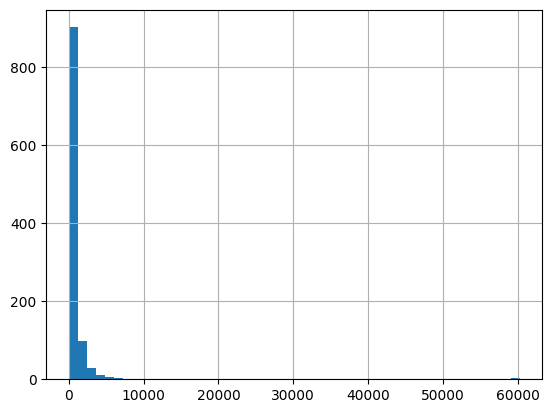

In [55]:
operator_volume = operator_calls.groupby('operator_id')['calls_count'].sum()

operator_volume.hist(bins=50)


In [56]:

# ver os operadores com números anormais de chamadas
operator_volume.sort_values(ascending=False).head(15)


operator_id
885890.0    60221
885876.0    59426
929428.0    23754
925922.0    20021
908640.0    14234
929426.0    11189
879898.0     7294
945286.0     6873
945302.0     6136
893804.0     5805
929424.0     5227
913938.0     5172
921318.0     4866
919364.0     4820
945322.0     4773
Name: calls_count, dtype: int64

In [57]:
#verificar valor abaixo do qual estão 99% dos operadores
operator_volume.quantile(0.99)

5197.300000000002

In [58]:
#mostrar os operadores que estão acima do comportamento de 99% da população
threshold = operator_volume.quantile(0.99)
outliers = operator_volume[operator_volume > threshold]
outliers

operator_id
879898.0     7294
885876.0    59426
885890.0    60221
893804.0     5805
908640.0    14234
925922.0    20021
929424.0     5227
929426.0    11189
929428.0    23754
945286.0     6873
945302.0     6136
Name: calls_count, dtype: int64

In [59]:
#indentificar operadores inválidos
valid_operators = operator_volume[operator_volume <= threshold].index
operator_calls_filtered = operator_calls[
    operator_calls['operator_id'].isin(valid_operators)
].copy()
operator_calls.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 36161 entries, 4 to 48996
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                                
---  ------               --------------  -----                                
 0   user_id              36161 non-null  int64                                
 1   date                 36161 non-null  datetime64[ns, pytz.FixedOffset(180)]
 2   direction            36161 non-null  object                               
 3   internal             36161 non-null  bool                                 
 4   operator_id          36161 non-null  float64                              
 5   is_missed_call       36161 non-null  bool                                 
 6   calls_count          36161 non-null  int64                                
 7   call_duration        36161 non-null  int64                                
 8   total_call_duration  36161 non-null  int64                                
dtypes: bool

A análise do volume de chamadas revelou a presença de operadores com atividade extremamente elevada, muito acima do comportamento observado para a maioria da população. Esses valores provavelmente representam processos automatizados ou funções operacionais distintas do atendimento humano.

Para garantir uma avaliação mais precisa da eficiência dos operadores, registros acima do percentil 99 foram excluídos da análise.

In [60]:
#verifica chamdas de operadores muito baixo
operator_volume.quantile(0.10)


2.0

In [61]:

#remover volume muito baixo de operadores
valid_operators = operator_volume[
    (operator_volume >= 30) &
    (operator_volume <= threshold)
].index
operator_calls_final = operator_calls[
    operator_calls['operator_id'].isin(valid_operators)
].copy()
operator_calls_final.shape
operator_calls_final['operator_id'].nunique()
operator_calls_final.shape

(32488, 9)

In [62]:

#validar se a bsae ficou equilibrada
operator_calls_final.groupby('operator_id')['calls_count'].sum().describe()


count     619.000000
mean      750.331179
std       938.846667
min        30.000000
25%        97.000000
50%       312.000000
75%      1138.500000
max      5172.000000
Name: calls_count, dtype: float64

Para avaliar corretamente a eficiência dos operadores, foi necessário definir um subconjunto analítico do dataset.

Chamadas sem identificação de operador foram excluídas, pois não é possível atribuir responsabilidade de atendimento quando não houve participação direta de um operador.

Além disso, chamadas internas também foram removidas, uma vez que não representam interações com clientes e, portanto, não refletem a performance operacional dos atendentes.

Em seguida, analisou-se a distribuição do volume de chamadas por operador, identificando grande variabilidade, incluindo operadores com atividade extremamente baixa e outros com volume muito superior ao restante da população.

Operadores com poucas chamadas não fornecem dados suficientes para uma avaliação confiável, enquanto volumes extremamente elevados podem indicar processos automatizados ou funções distintas do atendimento humano.

Portanto, foram estabelecidos critérios de inclusão considerando apenas operadores com pelo menos 30 chamadas e abaixo do percentil 99 de volume, garantindo maior comparabilidade e robustez nas análises subsequentes.

### Métricas de Eficiência

operator_id
879896.0     874
880020.0      41
880022.0     182
880026.0    2212
880028.0    2552
Name: calls_count, dtype: int64

count     619.000000
mean      750.331179
std       938.846667
min        30.000000
25%        97.000000
50%       312.000000
75%      1138.500000
max      5172.000000
Name: calls_count, dtype: float64

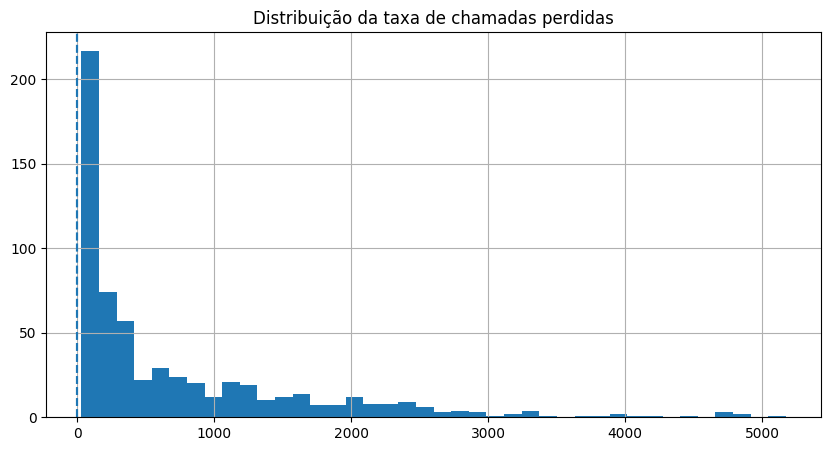

In [63]:
#volume de chamdas
calls_per_operator = operator_calls_final.groupby('operator_id')['calls_count'].sum()
display(calls_per_operator.head())
display(calls_per_operator.describe())


plt.figure(figsize=(10,5))
calls_per_operator.hist(bins=40)
plt.axvline(0.35, linestyle='--')  # mediana
plt.axvline(0.50, linestyle='--')  # zona crítica
plt.title("Distribuição da taxa de chamadas perdidas")
plt.show()


A distribuição do volume de chamadas apresenta assimetria à direita, indicando que a maioria dos operadores atende um número moderado de chamadas, enquanto um grupo menor concentra volumes mais elevados. O volume de chamadas foi utilizado como métrica de contexto, uma vez que maior produtividade não implica necessariamente maior eficiência. Operadores com alta carga podem enfrentar maior pressão operacional, o que deve ser considerado na interpretação das demais métricas.

operator_id
879896.0    0.362745
880020.0    0.235294
880022.0    0.338710
880026.0    0.437870
880028.0    0.394872
Name: is_missed_call, dtype: float64

count    619.000000
mean       0.336209
std        0.153920
min        0.000000
25%        0.250000
50%        0.351190
75%        0.473206
max        0.833333
Name: is_missed_call, dtype: float64

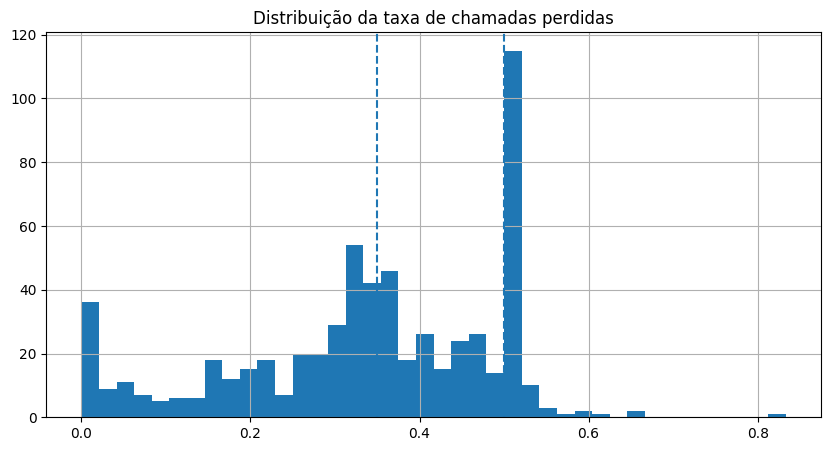

In [64]:
#taxa de chamadas perdidas 
missed_rate = operator_calls_final.groupby('operator_id')['is_missed_call'].mean()
display(missed_rate.head())
display(missed_rate.describe())


plt.figure(figsize=(10,5))
missed_rate.hist(bins=40)
plt.axvline(0.35, linestyle='--')  # mediana
plt.axvline(0.50, linestyle='--')  # zona crítica
plt.title("Distribuição da taxa de chamadas perdidas")
plt.show()




A análise da taxa de chamadas perdidas revelou um nível elevado de perdas em toda a operação, com mediana próxima de 35%

### Análise Exploratória de Dados (EDA)

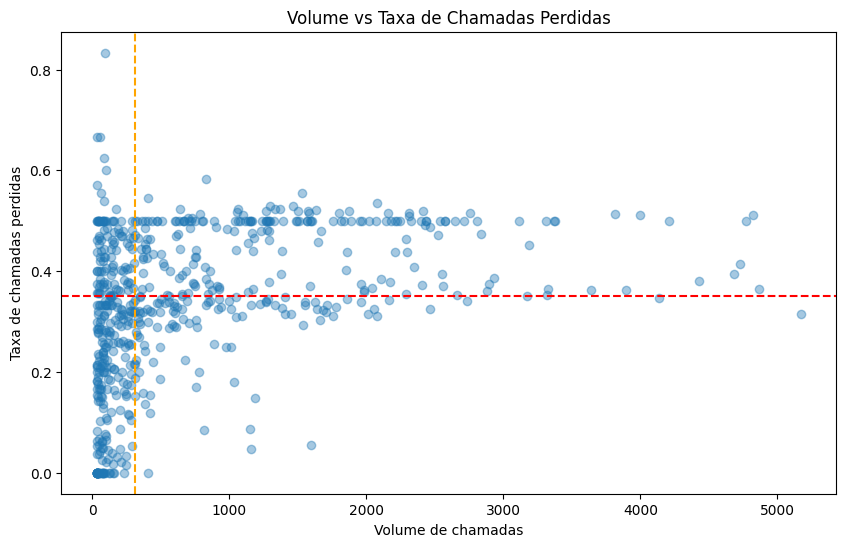

In [65]:
# volume X taxa de perdas

plt.figure(figsize=(10,6))

plt.scatter(
    calls_per_operator,
    missed_rate,
    alpha=0.4
)

# LINHAS MÁGICAS 👇
plt.axhline(0.35, color='red', linestyle='--')   # mediana perdas
plt.axvline(312, color='orange', linestyle='--') # mediana volume

plt.xlabel("Volume de chamadas")
plt.ylabel("Taxa de chamadas perdidas")
plt.title("Volume vs Taxa de Chamadas Perdidas")

plt.show()




operator_id
879896.0     85.321510
880020.0     61.121951
880022.0    103.939560
880026.0     79.336347
880028.0     74.094436
dtype: float64

count    619.000000
mean      98.526076
std       57.480241
min       11.559278
25%       64.020423
50%       85.920940
75%      116.880949
max      495.398374
dtype: float64

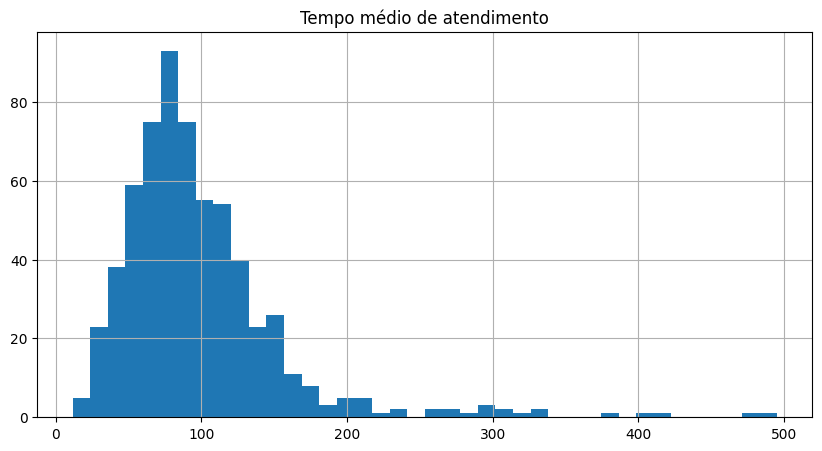

In [66]:
#tempo médio de atendimento

aht = operator_calls_final.groupby('operator_id')['total_call_duration'].sum() / \
      operator_calls_final.groupby('operator_id')['calls_count'].sum()

display(aht.head())
display(aht.describe())

plt.figure(figsize=(10,5))
aht.hist(bins=40)
plt.title("Tempo médio de atendimento")
plt.show()


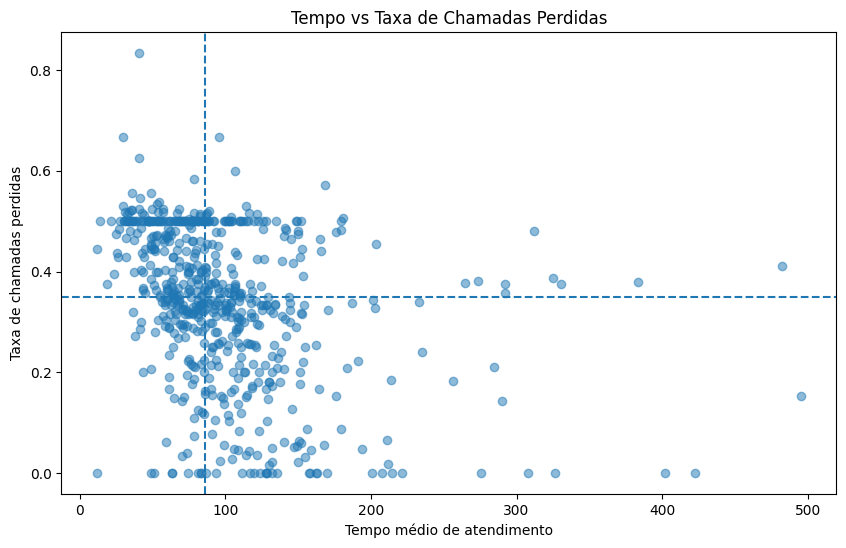

In [67]:
#tempo médio X taxa de perdas
plt.figure(figsize=(10,6))

plt.scatter(
    aht,
    missed_rate,
    alpha=0.5
)

plt.axhline(0.35, linestyle='--')  # mediana perdas
plt.axvline(86, linestyle='--')    # mediana tempo

plt.xlabel("Tempo médio de atendimento")
plt.ylabel("Taxa de chamadas perdidas")
plt.title("Tempo vs Taxa de Chamadas Perdidas")

plt.show()


A análise conjunta do tempo médio de atendimento e da taxa de chamadas perdidas não revelou uma relação direta entre maior duração e aumento das perdas.

In [68]:
#teste de capacidade
workload = calls_per_operator.sort_values(ascending=False)
workload.head(10)
workload.tail(10)


operator_id
899268.0    31
926872.0    31
935958.0    31
948150.0    31
931914.0    31
917846.0    30
916596.0    30
901894.0    30
951408.0    30
913868.0    30
Name: calls_count, dtype: int64

In [69]:
#medir desigualdade de carga
calls_per_operator.describe(percentiles=[0.1,0.25,0.5,0.75,0.9])


count     619.000000
mean      750.331179
std       938.846667
min        30.000000
10%        46.000000
25%        97.000000
50%       312.000000
75%      1138.500000
90%      2083.600000
max      5172.000000
Name: calls_count, dtype: float64

In [70]:
#correlação entre volume, taxa deperdas e tempo médio
analysis_df = pd.DataFrame({
    'volume': calls_per_operator,
    'missed_rate': missed_rate,
    'aht': aht
})

analysis_df.corr()



,volume,missed_rate,aht
volume,1.000000,0.375647,-0.207532
missed_rate,0.375647,1.000000,-0.358813
aht,-0.207532,-0.358813,1.000000


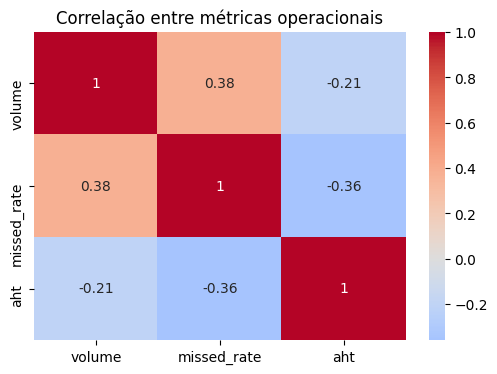

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(analysis_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Correlação entre métricas operacionais")
plt.show()


### Testes Estatísticos

In [72]:
#definir ocritério de operador ineficiente

volume_threshold = calls_per_operator.median()
missed_threshold = missed_rate.quantile(0.75)

analysis_df['inefficient'] = (
    (analysis_df['volume'] >= volume_threshold) &
    (analysis_df['missed_rate'] >= missed_threshold)
)

total_operators = len(analysis_df)
inefficient_count = analysis_df['inefficient'].sum()
efficient_count = total_operators - inefficient_count

print("Total de operadores:", total_operators)
print("Operadores classificados como ineficientes:", inefficient_count)
print("Operadores eficientes:", efficient_count)
print("Percentual de ineficientes:", round((inefficient_count/total_operators)*100,2), "%")


Total de operadores: 619
Operadores classificados como ineficientes: 119
Operadores eficientes: 500
Percentual de ineficientes: 19.22 %


In [73]:
#teste estátistico
#Grupo 1 → ineficientes
#Grupo 2 → restantes

from scipy.stats import ttest_ind

group_inefficient = analysis_df[analysis_df['inefficient']]['missed_rate']
group_efficient = analysis_df[~analysis_df['inefficient']]['missed_rate']

t_stat, p_value = ttest_ind(group_inefficient, group_efficient)

print("Teste t para diferença na taxa de chamadas perdidas")
print("---------------------------------------------------")
print("H0: Não há diferença na taxa média de perdas entre os grupos.")
print("H1: Operadores classificados como ineficientes têm maior taxa média de perdas.")
print("\nEstatística t:", round(t_stat, 3))
print("p-valor:", p_value)

alpha = 0.05

if p_value < alpha:
    print("\nConclusão: Rejeitamos H0. Existe diferença estatisticamente significativa.")
else:
    print("\nConclusão: Não rejeitamos H0. Não há evidência suficiente de diferença.")

print("\nMédia taxa de perdas - Ineficientes:", group_inefficient.mean())
print("Média taxa de perdas - Eficientes:", group_efficient.mean())


Teste t para diferença na taxa de chamadas perdidas
---------------------------------------------------
H0: Não há diferença na taxa média de perdas entre os grupos.
H1: Operadores classificados como ineficientes têm maior taxa média de perdas.

Estatística t: 15.576
p-valor: 2.2515209218240385e-46

Conclusão: Rejeitamos H0. Existe diferença estatisticamente significativa.

Média taxa de perdas - Ineficientes: 0.5036847137078047
Média taxa de perdas - Eficientes: 0.29634978150379243


O teste t indicou diferença estatisticamente significativa entre os grupos (t = 15.576, p < 0.001). Operadores classificados como ineficientes apresentam taxa média de perdas de aproximadamente 50%, significativamente superior aos 30% observados no restante da população

### Identificação de Operadores Ineficientes

In [74]:
#operadores ineficientes

inefficient_operators = analysis_df[analysis_df['inefficient']].copy()

inefficient_operators = inefficient_operators.sort_values(
    by='missed_rate',
    ascending=False
)
inefficient_operators.describe()


,volume,missed_rate,aht
count,119.000000,119.000000,119.000000
mean,1602.848739,0.503685,73.540060
std,936.869948,0.014488,34.353089
min,312.000000,0.473684,25.056085
25%,942.000000,0.500000,47.107695
50%,1368.000000,0.500000,69.755437
75%,2167.000000,0.502475,88.484912
max,4820.000000,0.583333,180.660432


In [75]:
summary = analysis_df.groupby('inefficient').agg({
    'volume': 'mean',
    'missed_rate': 'mean',
    'aht': 'mean'
})

summary


,volume,missed_rate,aht
inefficient,,,
False,547.432000,0.296350,104.472748
True,1602.848739,0.503685,73.540060


In [76]:
comparison_table = analysis_df.groupby('inefficient').agg({
    'volume': 'mean',
    'missed_rate': 'mean',
    'aht': 'mean'
}).round(2)

comparison_table.index = ['Eficientes', 'Ineficientes']

comparison_table


,volume,missed_rate,aht
Eficientes,547.43,0.3,104.47
Ineficientes,1602.85,0.5,73.54


### Dashboard e Visualizações    

In [77]:
#dataset final para Dashboard (Tableu)
analysis_df_export = analysis_df.reset_index()
analysis_df_export.rename(columns={'index': 'operator_id'}, inplace=True)

analysis_df_export.to_csv('dashboard_dataset.csv', index=False)

analysis_df_export.columns
analysis_df_export.head()


,operator_id,volume,missed_rate,aht,inefficient
0,879896.0,874,0.362745,85.321510,False
1,880020.0,41,0.235294,61.121951,False
2,880022.0,182,0.338710,103.939560,False
3,880026.0,2212,0.437870,79.336347,False
4,880028.0,2552,0.394872,74.094436,False


Com base nos critérios definidos, foram identificados 119 operadores (19% da população) com desempenho inferior ao padrão operacional. Esse grupo apresenta maior volume médio de chamadas, menor tempo médio de atendimento e taxa significativamente superior de chamadas perdidas, indicando possível influência de sobrecarga ou dinâmica operacional na eficiência observada.

* Sobre a eficiência dos operadores

A análise identificou que aproximadamente 19% dos operadores (119 de 619) apresentam desempenho inferior ao padrão operacional definido.

O critério utilizado considerou:

Volume de chamadas igual ou superior à mediana da distribuição;

Taxa de chamadas perdidas igual ou superior ao percentil 75.

Esse critério permitiu identificar operadores consistentemente acima do padrão observado na população.

* Diferenças entre grupos

A comparação entre operadores classificados como eficientes e ineficientes revelou que:

Operadores ineficientes atendem, em média, 1603 chamadas, enquanto os eficientes atendem 547 chamadas;

A taxa média de chamadas perdidas é de 50% no grupo ineficiente, contra 30% no grupo eficiente;

O tempo médio de atendimento é menor no grupo ineficiente (73s) em comparação com o grupo eficiente (104s).

* Validação Estatística

O teste t realizado indicou diferença estatisticamente significativa na taxa de chamadas perdidas entre os grupos (p < 0.001), confirmando que a diferença observada não é resultado de variação aleatória.

* Interpretação Analítica

Os resultados sugerem que a ineficiência identificada não está associada a maior tempo médio de atendimento.

Pelo contrário, operadores classificados como ineficientes apresentam menor tempo médio, porém maior taxa de perdas e maior volume de chamadas.

Esse padrão pode indicar associação entre:

maior carga operacional;

atendimento mais rápido;

aumento na taxa de chamadas perdidas.

In [78]:
#dataset final para Dashboard (Tableu)
analysis_df_export = analysis_df.reset_index()
analysis_df_export.rename(columns={'index': 'operator_id'}, inplace=True)

analysis_df_export.to_csv('dashboard_dataset.csv', index=False)

analysis_df_export.columns
analysis_df_export.head()



,operator_id,volume,missed_rate,aht,inefficient
0,879896.0,874,0.362745,85.321510,False
1,880020.0,41,0.235294,61.121951,False
2,880022.0,182,0.338710,103.939560,False
3,880026.0,2212,0.437870,79.336347,False
4,880028.0,2552,0.394872,74.094436,False


Links

Github:

Tableu: https://public.tableau.com/views/AnlisedeEficinciadeOperadoresCallMeMaybe/Painel1?:language=pt-BR&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

Google slides: https://docs.google.com/presentation/d/17GtQYbPLgnqU6iuihnErckVdvQK2mJzJVY27cRB_rnk/edit?usp=sharing
